In [1]:
import pandas as pd

interaction = pd.read_csv("../dataset/interactions.csv")
recipes = pd.read_csv("../dataset/recipes.csv")

print("=" * 65)
print("APERÇU INTERACTION")
print("=" * 65)
print(interaction.head())

print("=" * 65)
print("APERÇU RECIPES")
print("=" * 65)
print(recipes.head())


APERÇU INTERACTION
   user_id  recipe_id        date  rating  \
0    38094      40893  2003-02-17       4   
1  1293707      40893  2011-12-21       5   
2     8937      44394  2002-12-01       4   
3   126440      85009  2010-02-27       5   
4    57222      85009  2011-10-01       5   

                                              review  
0  Great with a salad. Cooked on top of stove for...  
1  So simple, so delicious! Great for chilly fall...  
2  This worked very well and is EASY.  I used not...  
3  I made the Mexican topping and took it to bunk...  
4  Made the cheddar bacon topping, adding a sprin...  
APERÇU RECIPES
                                         name      id  minutes  \
0  arriba   baked winter squash mexican style  137739       55   
1            a bit different  breakfast pizza   31490       30   
2                   all in the kitchen  chili  112140      130   
3                          alouette  potatoes   59389       45   
4          amish  tomato ketchup  f

Chargement des deux datasets avec **pandas**. La méthode **head()** affiche les 5 premières lignes.

- **interactions.csv** : notes et commentaires laissés sur les recettes
- **recipes.csv** : description des recettes

In [2]:
print("=" * 65)
print("INFORMATION INTERACTION")
print("=" * 65)
print(interaction.info())

print("=" * 65)
print("INFORMATION RECIPES")
print("=" * 65)
print(recipes.info())

INFORMATION INTERACTION
<class 'pandas.DataFrame'>
RangeIndex: 1132367 entries, 0 to 1132366
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1132367 non-null  int64
 1   recipe_id  1132367 non-null  int64
 2   date       1132367 non-null  str  
 3   rating     1132367 non-null  int64
 4   review     1132198 non-null  str  
dtypes: int64(3), str(2)
memory usage: 354.8 MB
None
INFORMATION RECIPES
<class 'pandas.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   name            231636 non-null  str  
 1   id              231637 non-null  int64
 2   minutes         231637 non-null  int64
 3   contributor_id  231637 non-null  int64
 4   submitted       231637 non-null  str  
 5   tags            231637 non-null  str  
 6   nutrition       231637 non-null  str  
 7   n_steps         23163

La méthode **info()** donne la taille, les colonnes et les types.

- interactions : 1 132 367 lignes, 5 colonnes
- recipes : 231 637 lignes, 12 colonnes
- **date** et **submitted** sont stockées en texte, elles seront converties
- **tags**, **nutrition** et **ingredients** sont du texte représentant des listes

In [3]:
print("=" * 65)
print("STATISTIQUE INTERACTION")
print("=" * 65)
print(interaction.describe())

print("=" * 65)
print("STATISTIQUE RECIPES")
print("=" * 65)
print(recipes.describe())

STATISTIQUE INTERACTION
            user_id     recipe_id        rating
count  1.132367e+06  1.132367e+06  1.132367e+06
mean   1.384291e+08  1.608972e+05  4.411016e+00
std    5.014269e+08  1.303987e+05  1.264752e+00
min    1.533000e+03  3.800000e+01  0.000000e+00
25%    1.354700e+05  5.425700e+04  4.000000e+00
50%    3.309370e+05  1.205470e+05  5.000000e+00
75%    8.045500e+05  2.438520e+05  5.000000e+00
max    2.002373e+09  5.377160e+05  5.000000e+00
STATISTIQUE RECIPES


                  id       minutes  contributor_id        n_steps  \
count  231637.000000  2.316370e+05    2.316370e+05  231637.000000   
mean   222014.708984  9.398546e+03    5.534885e+06       9.765499   
std    141206.635626  4.461963e+06    9.979141e+07       5.995128   
min        38.000000  0.000000e+00    2.700000e+01       0.000000   
25%     99944.000000  2.000000e+01    5.690500e+04       6.000000   
50%    207249.000000  4.000000e+01    1.736140e+05       9.000000   
75%    333816.000000  6.500000e+01    3.982750e+05      12.000000   
max    537716.000000  2.147484e+09    2.002290e+09     145.000000   

       n_ingredients  
count  231637.000000  
mean        9.051153  
std         3.734796  
min         1.000000  
25%         6.000000  
50%         9.000000  
75%        11.000000  
max        43.000000  


La méthode **describe()** donne les statistiques des variables numériques.

- **rating** : moyenne 4,41, médiane 5, minimum 0
- **minutes** : médiane 40, maximum 2 147 483 647, valeur aberrante
- **n_steps** : médiane 9, maximum 145, minimum 0
- **n_ingredients** : médiane 9, maximum 43

In [4]:
print("=" * 65)
print("VALEURS MANQUANTES INTERACTION")
print("=" * 65)
print(interaction.isna().sum())

print("=" * 65)
print("VALEURS MANQUANTES RECIPES")
print("=" * 65)
print(recipes.isna().sum())

VALEURS MANQUANTES INTERACTION
user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64
VALEURS MANQUANTES RECIPES
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64


Les méthodes **isna()** et **sum()** comptent les valeurs manquantes.

- interactions : 169 commentaires manquants, aucune note manquante
- recipes : 1 nom et 4 979 descriptions manquants
- aucune variable utile au filtrage collaboratif n'est touchée

In [5]:
print("=" * 65)
print("NOMBRE D'INTERACTION PAR RECETTE")
print("=" * 65)

nombre_interaction = interaction.groupby("recipe_id")["rating"].agg(["count", "mean"])

print(nombre_interaction.describe())

NOMBRE D'INTERACTION PAR RECETTE
               count           mean
count  231637.000000  231637.000000
mean        4.888541       4.346246
std        17.532481       0.990806
min         1.000000       0.000000
25%         1.000000       4.000000
50%         2.000000       4.714286
75%         4.000000       5.000000
max      1613.000000       5.000000


La méthode **groupby()** avec **agg()** calcule le nombre de notes et la note moyenne de chaque recette.

- 4,89 notes par recette en moyenne
- médiane à 2 notes
- maximum 1 613 notes
- un quart des recettes n'a reçu qu'une seule note

In [6]:
print("=" * 65)
print("CONVERSION DES DATES")
print("=" * 65)

interaction["date"] = pd.to_datetime(interaction["date"])
recipes["submitted"] = pd.to_datetime(recipes["submitted"])

print("interaction :", interaction["date"].min(), "->", interaction["date"].max())
print("recettes :", recipes["submitted"].min(), "->", recipes["submitted"].max())

CONVERSION DES DATES


interaction : 2000-01-25 00:00:00 -> 2018-12-20 00:00:00
recettes : 1999-08-06 00:00:00 -> 2018-12-04 00:00:00


La méthode **to_datetime()** convertit **date** et **submitted** en dates.

- interactions : du 25 janvier 2000 au 20 décembre 2018
- recettes : du 6 août 1999 au 4 décembre 2018

In [7]:
import ast

print("=" * 65)
print("DECOUPAGE DES NUTRITIONS")
print("=" * 65)

nutritions_table = ["calories", "total_fat", "sugar", "sodium", "protein", "sat_fat", "carbs"]

liste_nutrition = recipes["nutrition"].apply(ast.literal_eval)
recipes[nutritions_table] = pd.DataFrame(liste_nutrition.tolist(), index = recipes.index)

print(recipes[nutritions_table].head())

DECOUPAGE DES NUTRITIONS


   calories  total_fat  sugar  sodium  protein  sat_fat  carbs
0      51.5        0.0   13.0     0.0      2.0      0.0    4.0
1     173.4       18.0    0.0    17.0     22.0     35.0    1.0
2     269.8       22.0   32.0    48.0     39.0     27.0    5.0
3     368.1       17.0   10.0     2.0     14.0      8.0   20.0
4     352.9        1.0  337.0    23.0      3.0      0.0   28.0


La variable **nutrition** est un texte représentant une liste de 7 valeurs. La fonction **ast.literal_eval()** la transforme en liste python.

Sept colonnes sont créées : calories, total_fat, sugar, sodium, protein, sat_fat, carbs. Les six dernières sont exprimées en pourcentage des apports journaliers recommandés.

In [8]:
print("=" * 65)
print("CONVERSION DES TAGS ET INGREDIENTS EN LISTES")
print("=" * 65)

recipes["tags"] = recipes["tags"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
recipes["ingredients"] = recipes["ingredients"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print(type(recipes["tags"][0]))
print(recipes["ingredients"][0])

CONVERSION DES TAGS ET INGREDIENTS EN LISTES


<class 'list'>
['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter', 'olive oil', 'salt']


Les variables **tags** et **ingredients** sont aussi du texte représentant des listes. **ast.literal_eval()** les convertit.

La condition **isinstance(x, str)** évite une erreur si la cellule est relancée.

In [9]:
print("=" * 65)
print("VARIABLES DE RANG")
print("=" * 65)

notes = interaction[interaction["rating"] > 0]
print("Notes à 0 retirées :", len(interaction) - len(notes))

stats_recette = notes.groupby("recipe_id")["rating"].agg(note_moyenne = "mean", nb_notes = "count")

stats_recette["rang_note_moyenne"] = stats_recette["note_moyenne"].rank(ascending = False, method = "min")
stats_recette["rang_nb_notes"] = stats_recette["nb_notes"].rank(ascending = False, method = "min")

recipes = recipes.merge(stats_recette, left_on="id", right_index=True, how="left")

print(recipes[["name", "note_moyenne", "nb_notes", "rang_note_moyenne", "rang_nb_notes"]].sort_values("rang_nb_notes").head(10))


VARIABLES DE RANG


Notes à 0 retirées : 60847


                                                     name  note_moyenne  \
213826                         to die for crock pot roast      4.589572   
66687   crock pot chicken with black beans   cream cheese      4.478495   
22168                                   best banana bread      4.819415   
62431                          creamy cajun chicken pasta      4.838852   
22388    best ever banana cake with cream cheese frosting      4.793132   
229262            yes  virginia there is a great meatloaf      4.652284   
574                   whatever floats your boat  brownies      4.780087   
115303                   jo mama s world famous spaghetti      4.729636   
118161   kittencal s italian melt in your mouth meatballs      4.894682   
114444                             japanese mum s chicken      4.639440   

        nb_notes  rang_note_moyenne  rang_nb_notes  
213826    1496.0           145777.0            1.0  
66687     1488.0           163456.0            2.0  
22168     1401.

Les notes à **0** sont retirées. Elles signalent une absence de note et non une mauvaise évaluation.

- 60 847 notes retirées, soit 5,37 % du total
- la méthode **rank()** classe les recettes par note moyenne et par nombre de notes
- la méthode **merge()** ajoute ces variables au dataset recipes

La recette la plus notée est *to die for crock pot roast*, avec 1 496 notes pour une moyenne de 4,59. Son rang par note moyenne n'est que 145 777. Les deux classements sont donc indépendants.

ETUDE DE LA VARIABLE RATING
        nombre  pourcentage
rating                     
0        60847         5.37
1        12818         1.13
2        14123         1.25
3        40855         3.61
4       187360        16.55
5       816364        72.09
Moyenne (avec les 0) : 4.41
Moyenne (sans les 0) : 4.66
Médiane : 5.0


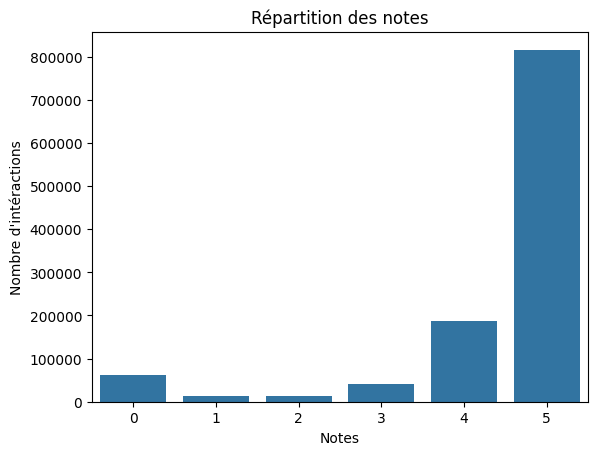

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 65)
print("ETUDE DE LA VARIABLE RATING")
print("=" * 65)

repartition = interaction["rating"].value_counts().sort_index()
pourcentage = interaction["rating"].value_counts(normalize=True).sort_index() * 100

print(pd.DataFrame({"nombre": repartition, "pourcentage": pourcentage.round(2)}))

print("Moyenne (avec les 0) :", round(interaction["rating"].mean(), 2))
print("Moyenne (sans les 0) :", round(notes["rating"].mean(), 2))
print("Médiane :", interaction["rating"].median())

sns.countplot(x = "rating", data = interaction)
plt.title("Répartition des notes")
plt.xlabel("Notes")
plt.ylabel("Nombre d'intéractions")
plt.show()

Répartition des notes.

| Note | Nombre | Part |
|---|---|---|
| 5 | 816 364 | 72,09 % |
| 4 | 187 360 | 16,55 % |
| 0 | 60 847 | 5,37 % |
| 3 | 40 855 | 3,61 % |
| 2 | 14 123 | 1,25 % |
| 1 | 12 818 | 1,13 % |

- moyenne 4,41 avec les 0, 4,66 sans
- médiane 5

Les notes sont très déséquilibrées. Près de 9 notes sur 10 valent 4 ou 5. Cette concentration limitera l'intérêt de la RMSE dans la partie suivante.

ETUDE DE LA VARIABLE DATE
date
2000       108
2001      2904
2002     20922
2003     32961
2004     45950
2005     66643
2006     89794
2007    141158
2008    167295
2009    159445
2010    107409
2011     72147
2012     56410
2013     49488
2014     30503
2015     23374
2016     18147
2017     27062
2018     20647
Name: count, dtype: int64


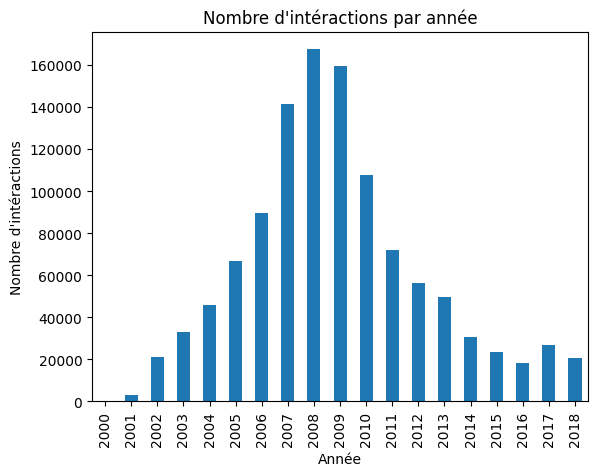

In [11]:
print("=" * 65)
print("ETUDE DE LA VARIABLE DATE")
print("=" * 65)

interaction_par_annee = interaction["date"].dt.year.value_counts().sort_index()
print(interaction_par_annee)

interaction_par_annee.plot(kind="bar")
plt.title("Nombre d'intéractions par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'intéractions")
plt.show()

Nombre d'interactions par année.

- première interaction en janvier 2000, dernière en décembre 2018
- pic en 2008 avec 167 295 interactions
- baisse continue ensuite, 20 647 interactions en 2018
- l'activité du site a donc chuté de 88 % entre 2008 et 2018

ETUDE DE LA VARIABLE USER
count    226570.000000
mean          4.997868
std          49.663111
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        7671.000000
dtype: float64
Utilisateur avec une seule interaction: 166256
Part (%) : 73.38
user_id
424680    7671
37449     5603
383346    4628
169430    4076
128473    3917
dtype: int64


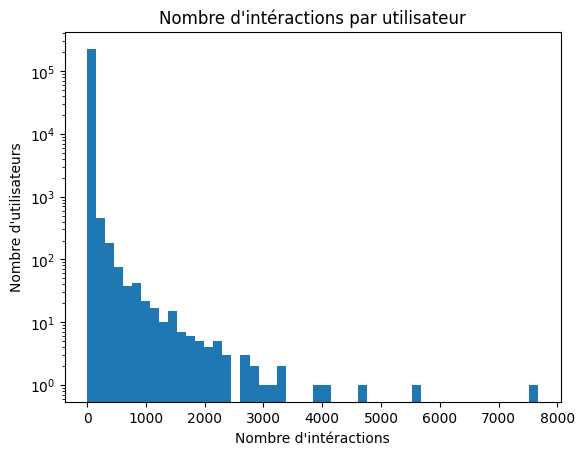

In [12]:
print("=" * 65)
print("ETUDE DE LA VARIABLE USER")
print("=" * 65)

interaction_par_user = interaction.groupby("user_id").size()
print(interaction_par_user.describe())
print("Utilisateur avec une seule interaction:", (interaction_par_user == 1).sum())
print("Part (%) :", round((interaction_par_user == 1).mean() * 100, 2))
print(interaction_par_user.sort_values(ascending=False).head(5))

interaction_par_user.plot(kind="hist", bins=50, logy=True)
plt.title("Nombre d'intéractions par utilisateur")
plt.xlabel("Nombre d'intéractions")
plt.ylabel("Nombre d'utilisateurs")
plt.show()

Nombre d'interactions par utilisateur. L'échelle verticale est logarithmique pour rendre visibles les valeurs rares.

- 226 570 utilisateurs
- 73,38 % n'ont qu'une seule interaction
- médiane 1, moyenne 5,0
- maximum 7 671 interactions

La distribution suit une longue traîne. La majorité des utilisateurs n'apporte presque aucune information.

ETUDE DE LA VARIABLE RECIPE
count    231637.000000
mean          4.888541
std          17.532481
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1613.000000
dtype: float64
Recette avec une seule interaction: 91953
Part (%) : 39.7
Recette avec au moins 100 intéractions : 787
recipe_id
2886     1613
27208    1601
89204    1579
39087    1448
67256    1322
dtype: int64


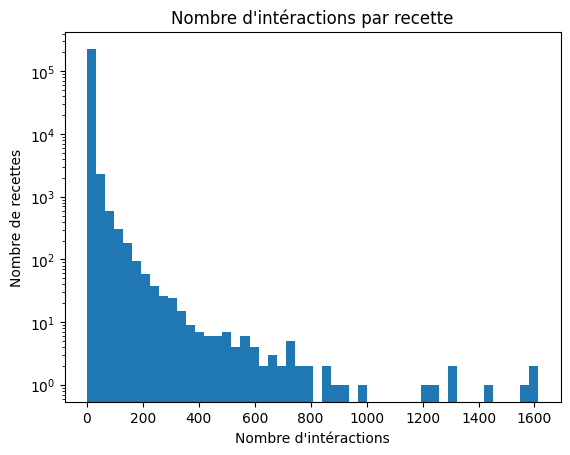

In [13]:
print("=" * 65)
print("ETUDE DE LA VARIABLE RECIPE")
print("=" * 65)

interaction_par_recette = interaction.groupby("recipe_id").size()
print(interaction_par_recette.describe())
print("Recette avec une seule interaction:", (interaction_par_recette == 1).sum())
print("Part (%) :", round((interaction_par_recette == 1).mean() * 100, 2))
print("Recette avec au moins 100 intéractions :", (interaction_par_recette >= 100).sum())
print(interaction_par_recette.sort_values(ascending=False).head(5))

interaction_par_recette.plot(kind="hist", bins=50, logy=True)
plt.title("Nombre d'intéractions par recette")
plt.xlabel("Nombre d'intéractions")
plt.ylabel("Nombre de recettes")
plt.show()

Nombre d'interactions par recette. L'échelle verticale est également logarithmique.

- 231 637 recettes
- 39,7 % n'ont reçu qu'une seule note
- médiane 2, moyenne 4,89
- 787 recettes seulement dépassent 100 interactions
- maximum 1 613 notes

Même longue traîne que pour les utilisateurs, moins marquée.

ETUDE DES VARIABLES DE RECIPES
minutes        mediane     40.0 | moyenne     9398.5 | max     2147483647 | au-dela de 240 : 12969 (5.60 %)
n_steps        mediane      9.0 | moyenne        9.8 | max            145 | au-dela de 40 : 548 (0.24 %)
n_ingredients  mediane      9.0 | moyenne        9.1 | max             43 | au-dela de 25 : 235 (0.10 %)
calories       mediane    313.4 | moyenne      473.9 | max         434360 | au-dela de 2000 : 6072 (2.62 %)


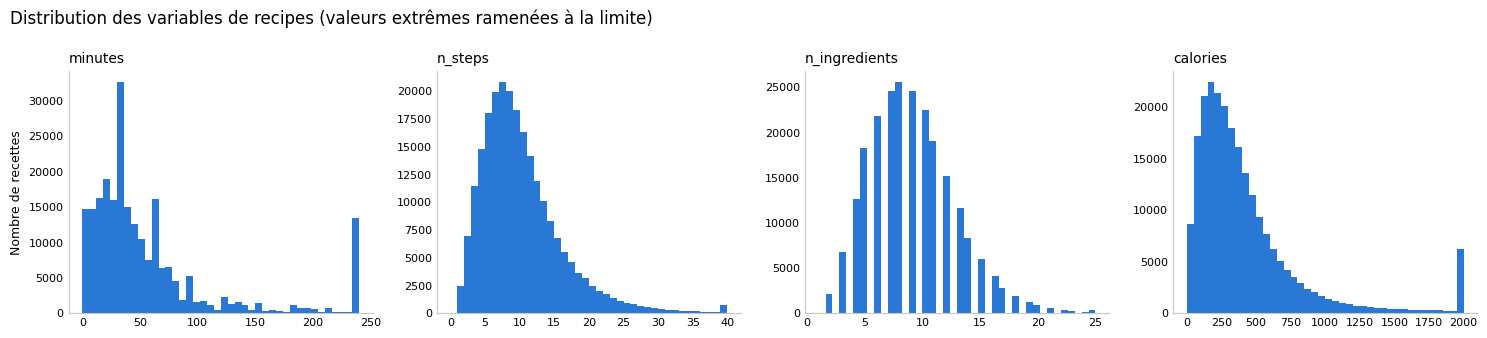

In [14]:
print("=" * 65)
print("ETUDE DES VARIABLES DE RECIPES")
print("=" * 65)

BLEU, GRIS, ENCRE = "#2a78d6", "#c9c8bf", "#52514e"

def habille(axe, titre, x=None, y=None):
    axe.set_title(titre, loc="left", fontsize=10)
    if x:
        axe.set_xlabel(x, fontsize=9)
    if y:
        axe.set_ylabel(y, fontsize=9)
    axe.tick_params(labelsize=8, length=0)
    for cote in ("top", "right"):
        axe.spines[cote].set_visible(False)
    for cote in ("left", "bottom"):
        axe.spines[cote].set_color(GRIS)

variables = {"minutes": 240, "n_steps": 40, "n_ingredients": 25, "calories": 2000}
for colonne, limite in variables.items():
    serie = recipes[colonne]
    hors = (serie > limite).sum()
    print(f"{colonne:14s} mediane {serie.median():8.1f} | moyenne {serie.mean():10.1f} | "
          f"max {serie.max():14.0f} | au-dela de {limite} : {hors} ({100 * hors / len(serie):.2f} %)")

figure, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for axe, (colonne, limite) in zip(axes, variables.items()):
    axe.hist(recipes[colonne].clip(upper=limite), bins=40, color=BLEU)
    habille(axe, colonne, y="Nombre de recettes" if colonne == "minutes" else None)
figure.suptitle("Distribution des variables de recipes (valeurs extrêmes ramenées à la limite)",
                x=0.01, ha="left", fontsize=12)
figure.tight_layout()
plt.show()

Les quatre variables numériques de recipes.

| Variable | Médiane | Moyenne | Maximum | Valeurs extrêmes |
|---|---|---|---|---|
| minutes | 40 | 9 398 | 2 147 483 647 | 5,60 % au-delà de 240 |
| n_steps | 9 | 9,8 | 145 | 0,24 % au-delà de 40 |
| n_ingredients | 9 | 9,1 | 43 | 0,10 % au-delà de 25 |
| calories | 313 | 474 | 434 360 | 2,62 % au-delà de 2 000 |

- le maximum de **minutes** vaut 2 147 483 647, soit la plus grande valeur d'un entier 32 bits
- cette valeur est une erreur de saisie, elle tire la moyenne à 9 398 minutes alors que la médiane vaut 40
- la méthode **clip()** ramène les valeurs extrêmes à la limite, sinon les histogrammes seraient illisibles
- les quatre distributions sont asymétriques à droite, la recette type est courte et simple

TAGS ET INGREDIENTS LES PLUS FREQUENTS


Tags différents          : 552
Ingrédients différents   : 14942
Tags par recette         : 17.9


Ingrédients par recette  : 9.1


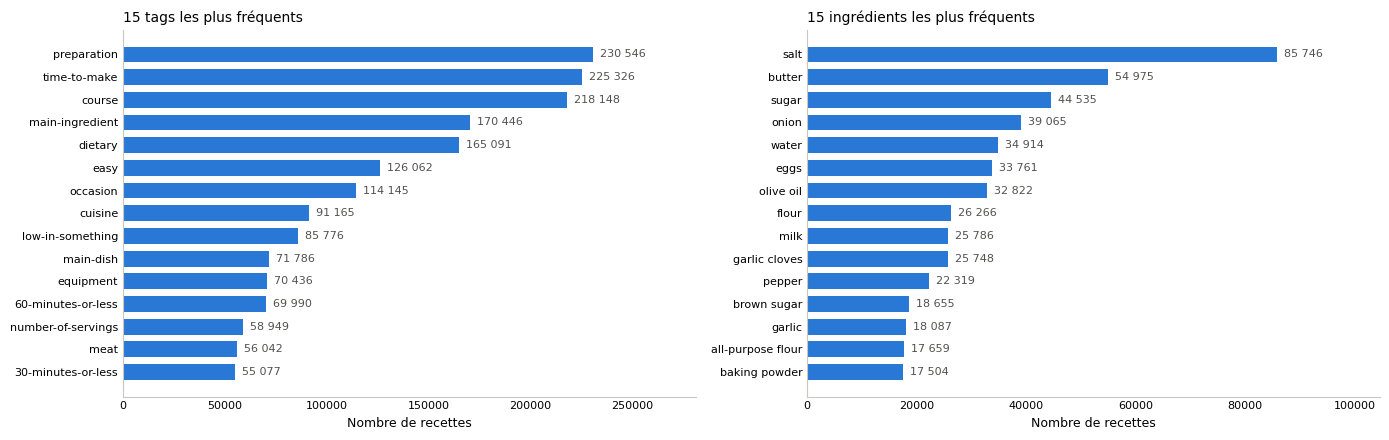

In [15]:
print("=" * 65)
print("TAGS ET INGREDIENTS LES PLUS FREQUENTS")
print("=" * 65)

tous_tags = pd.Series([tag for liste in recipes["tags"] for tag in liste])
tous_ingredients = pd.Series([ing for liste in recipes["ingredients"] for ing in liste])
top_tags = tous_tags.value_counts().head(15)
top_ingredients = tous_ingredients.value_counts().head(15)

print("Tags différents          :", tous_tags.nunique())
print("Ingrédients différents   :", tous_ingredients.nunique())
print("Tags par recette         :", round(recipes["tags"].str.len().mean(), 1))
print("Ingrédients par recette  :", round(recipes["ingredients"].str.len().mean(), 1))

figure, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for axe, serie, titre in ((axes[0], top_tags, "15 tags les plus fréquents"),
                          (axes[1], top_ingredients, "15 ingrédients les plus fréquents")):
    serie = serie.sort_values()
    axe.barh(serie.index, serie.values, color=BLEU, height=0.7)
    for nom, valeur in serie.items():
        axe.text(valeur, nom, f"  {valeur:,}".replace(",", " "), va="center", fontsize=8, color=ENCRE)
    axe.set_xlim(0, serie.max() * 1.22)
    habille(axe, titre, x="Nombre de recettes")
figure.tight_layout()
plt.show()

Les variables **tags** et **ingredients** ont été converties en listes plus haut. Elles sont ici dépliées pour compter les valeurs les plus fréquentes.

- 552 tags différents, 17,9 par recette en moyenne
- 14 942 ingrédients différents, 9,1 par recette
- les tags les plus fréquents sont des catégories générales : preparation (230 546), time-to-make (225 326), course (218 148)
- ces trois tags couvrent presque tout le catalogue, ils ne distinguent donc pas les recettes
- les ingrédients les plus fréquents sont des produits de base : salt (85 746), butter (54 975), sugar (44 535)

Ces variables ne servent pas au filtrage collaboratif, qui n'utilise que les notes. Elles seraient la base d'une approche par contenu.

CONCENTRATION DES INTERACTIONS
recettes     : les   1% les plus actifs concentrent 23.4% des interactions
recettes     : les   5% les plus actifs concentrent 43.1% des interactions
recettes     : les  10% les plus actifs concentrent 54.8% des interactions
recettes     : les  20% les plus actifs concentrent 68.5% des interactions
utilisateurs : les   1% les plus actifs concentrent 51.2% des interactions
utilisateurs : les   5% les plus actifs concentrent 69.9% des interactions
utilisateurs : les  10% les plus actifs concentrent 76.8% des interactions
utilisateurs : les  20% les plus actifs concentrent 82.7% des interactions


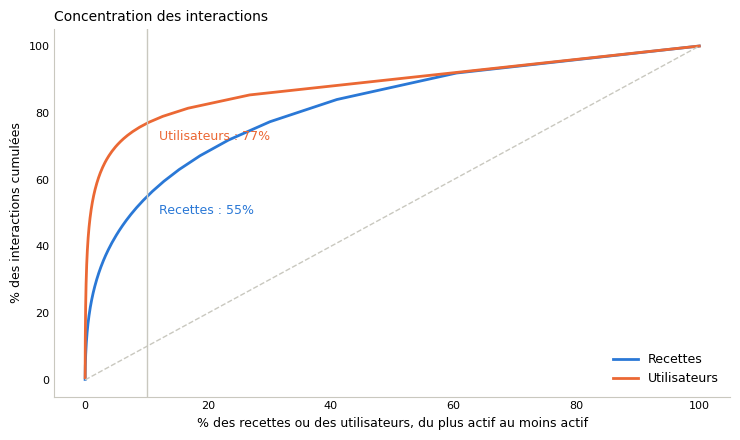

In [16]:
import numpy as np

print("=" * 65)
print("CONCENTRATION DES INTERACTIONS")
print("=" * 65)

par_recette = interaction["recipe_id"].value_counts().sort_values(ascending=False)
par_utilisateur = interaction["user_id"].value_counts().sort_values(ascending=False)

for nom, serie in (("recettes", par_recette), ("utilisateurs", par_utilisateur)):
    cumul = serie.cumsum() / serie.sum()
    for part in (0.01, 0.05, 0.10, 0.20):
        indice = int(part * len(serie)) - 1
        print(f"{nom:12s} : les {part:4.0%} les plus actifs concentrent "
              f"{cumul.iloc[indice]:5.1%} des interactions")

figure, axe = plt.subplots(figsize=(7.5, 4.5))
for serie, couleur, nom in ((par_recette, BLEU, "Recettes"), (par_utilisateur, "#eb6834", "Utilisateurs")):
    cumul = serie.cumsum() / serie.sum()
    rang = np.arange(1, len(serie) + 1) / len(serie)
    axe.plot(rang * 100, cumul * 100, color=couleur, linewidth=2, label=nom)
    indice = int(0.10 * len(serie)) - 1
    axe.annotate(f"{nom} : {cumul.iloc[indice]:.0%}", xy=(12, cumul.iloc[indice] * 100 - 5),
                 color=couleur, fontsize=9)
axe.plot([0, 100], [0, 100], color=GRIS, linewidth=1, linestyle="--")
axe.axvline(10, color=GRIS, linewidth=1)
axe.legend(frameon=False, fontsize=9, loc="lower right")
habille(axe, "Concentration des interactions", "% des recettes ou des utilisateurs, du plus actif au moins actif",
        "% des interactions cumulées")
figure.tight_layout()
plt.show()

Part des interactions concentrée par les utilisateurs et les recettes les plus actifs. La diagonale en pointillés représenterait une répartition parfaitement égale.

| Part la plus active | Recettes | Utilisateurs |
|---|---|---|
| 1 % | 23,4 % | 51,2 % |
| 5 % | 43,1 % | 69,9 % |
| 10 % | 54,8 % | 76,8 % |
| 20 % | 68,5 % | 82,7 % |

- 1 % des utilisateurs produisent plus de la moitié des interactions
- 10 % des recettes concentrent 55 % des notes
- la concentration est donc plus forte côté utilisateurs que côté recettes


NOTE MOYENNE SELON L'ANNEE ET LA POPULARITE
       mean   count
date               
2000  4.270     100
2001  4.424    2622
2002  4.648   20022
2003  4.682   32035
2004  4.681   44676
2005  4.721   64702
2006  4.691   87918
2007  4.604  139350
2008  4.661  161251
2009  4.699  153437
2010  4.702  101668
2011  4.688   66272
2012  4.685   52094
2013  4.660   45142
2014  4.625   27222
2015  4.507   20881
2016  4.514   15877
2017  4.528   20160
2018  4.508   16091
           mean  count
nb_notes              
1         4.511  91698
2         4.566  44455
3-5       4.632  49840
6-10      4.684  23045
11-50     4.701  15636
51-100    4.707   1216
100+      4.714    700


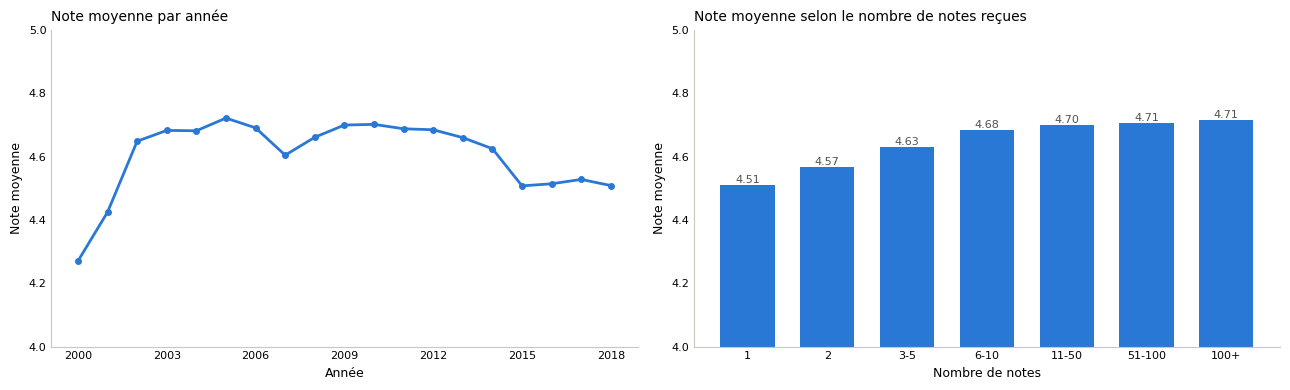

In [17]:
print("=" * 65)
print("NOTE MOYENNE SELON L'ANNEE ET LA POPULARITE")
print("=" * 65)

note_par_annee = notes.groupby(notes["date"].dt.year)["rating"].agg(["mean", "count"])
print(note_par_annee.round(3).to_string())

tranches = pd.cut(recipes["nb_notes"], [0, 1, 2, 5, 10, 50, 100, 10000],
                  labels=["1", "2", "3-5", "6-10", "11-50", "51-100", "100+"])
note_par_tranche = recipes.groupby(tranches, observed=True)["note_moyenne"].agg(["mean", "count"])
print(note_par_tranche.round(3).to_string())

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(note_par_annee.index, note_par_annee["mean"], color=BLEU, linewidth=2, marker="o", markersize=4)
axes[0].set_xticks(range(2000, 2019, 3))
axes[0].set_ylim(4, 5)
habille(axes[0], "Note moyenne par année", "Année", "Note moyenne")

axes[1].bar(note_par_tranche.index.astype(str), note_par_tranche["mean"], color=BLEU, width=0.68)
for i, valeur in enumerate(note_par_tranche["mean"]):
    axes[1].text(i, valeur, f"{valeur:.2f}", ha="center", va="bottom", fontsize=8, color=ENCRE)
axes[1].set_ylim(4, 5)
habille(axes[1], "Note moyenne selon le nombre de notes reçues", "Nombre de notes", "Note moyenne")
figure.tight_layout()
plt.show()

Note moyenne par année :
- 4,27 en 2000, 4,72 au maximum en 2005, 4,51 en 2018
- l'écart reste inférieur à 0,5 point sur 19 ans
- la date n'explique donc presque rien de la note

Note moyenne selon le nombre de notes reçues :
- 4,51 pour les recettes notées une seule fois
- 4,71 pour celles notées plus de 100 fois
- les recettes populaires sont donc mieux notées

Ce second résultat est un biais de popularité. Il devra être gardé en tête lors de la lecture des recommandations : proposer les recettes les plus notées revient en partie à proposer les mieux notées.

# Filtrage collaboratif sur le dataset interactions.csv

La démarche comporte six étapes :
- la préparation des données
- la définition des hyperparamètres de chaque algorithme
- la recherche des meilleurs hyperparamètres
- le calcul des métriques (MAE, RMSE, Hit Rate, etc.)
- la comparaison des algorithmes
- la création d'une fonction de recommandation

In [18]:
print("=" * 65)
print("PRÉPARATION DU JEU POUR LE FILTRAGE COLLABORATIF")
print("=" * 65)

SEUIL_UTILISATEUR = 15
SEUIL_RECETTE = 15

cf = notes.drop_duplicates(subset=["user_id", "recipe_id"], keep="last")
print("Doublons (utilisateur, recette) retirés :", len(notes) - len(cf))

while True:
    nb_par_user = cf["user_id"].map(cf["user_id"].value_counts())
    nb_par_recette = cf["recipe_id"].map(cf["recipe_id"].value_counts())
    masque = (nb_par_user >= SEUIL_UTILISATEUR) & (nb_par_recette >= SEUIL_RECETTE)
    if masque.all():
        break
    cf = cf[masque]

cf = cf[["user_id", "recipe_id", "rating"]].reset_index(drop=True)
nb_utilisateurs = cf["user_id"].nunique()
nb_recettes = cf["recipe_id"].nunique()

print("Notes conservées   :", len(cf), "(", round(100 * len(cf) / len(notes), 1), "% des notes )")
print("Utilisateurs       :", nb_utilisateurs)
print("Recettes           :", nb_recettes)
print("Densité (%)        :", round(100 * len(cf) / (nb_utilisateurs * nb_recettes), 3))
print("Notes par utilisateur (moyenne) :", round(len(cf) / nb_utilisateurs, 1))
print("Notes par recette (moyenne)     :", round(len(cf) / nb_recettes, 1))
print("-" * 65)
print("Matrice de similarité utilisateur-utilisateur :", round(nb_utilisateurs ** 2 * 8 / 1e6), "Mo")
print("Matrice de similarité recette-recette         :", round(nb_recettes ** 2 * 8 / 1e6), "Mo")

PRÉPARATION DU JEU POUR LE FILTRAGE COLLABORATIF
Doublons (utilisateur, recette) retirés : 0


Notes conservées   : 179654 ( 16.8 % des notes )
Utilisateurs       : 3807
Recettes           : 5433
Densité (%)        : 0.869
Notes par utilisateur (moyenne) : 47.2
Notes par recette (moyenne)     : 33.1
-----------------------------------------------------------------
Matrice de similarité utilisateur-utilisateur : 116 Mo
Matrice de similarité recette-recette         : 236 Mo


La matrice utilisateur / recette est très déséquilibré. Le dataset contient 226 570 utilisateurs et 231 637 recettes. La plupart d'entre eux ne possèdent qu'une seule interaction.

On observe :
- le noyau conserve 179 654 notes, soit 16,8 % des notes de départ
- il contient 3 807 utilisateurs et 5 433 recettes
- la densité passe de 0,002 % à 0,869 %, elle est donc environ 400 fois plus élevée
- chaque utilisateur note en moyenne 47,2 recettes
- chaque recette reçoit en moyenne 33,1 notes
- aucun doublon utilisateur / recette n'était présent dans le dataset

In [19]:
from surprise import Reader, Dataset
from surprise.model_selection import train_test_split

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("=" * 65)
print("CHARGEMENT DANS SURPRISE")
print("=" * 65)

reader = Reader(rating_scale=(1, 5))
donnees = Dataset.load_from_df(cf[["user_id", "recipe_id", "rating"]], reader)

trainset, testset = train_test_split(donnees, test_size=0.25, random_state=42)
trainset_complet = donnees.build_full_trainset()

print("Apprentissage :", trainset.n_ratings, "notes /", trainset.n_users,
      "utilisateurs /", trainset.n_items, "recettes")
print("Test          :", len(testset), "notes")
print("Note moyenne globale (apprentissage) :", round(trainset.global_mean, 3))

CHARGEMENT DANS SURPRISE


Apprentissage : 134740 notes / 3807 utilisateurs / 5433 recettes
Test          : 44914 notes
Note moyenne globale (apprentissage) : 4.741


On observe :
- le jeu d'apprentissage contient 134 740 notes
- le jeu de test contient 44 914 notes
- la note moyenne du jeu d'apprentissage vaut 4,741

Cette moyenne est très élevée. Les notes sont donc concentrées sur 4 et 5. Un modèle qui prédirait toujours 4,74 obtiendrait déjà une erreur faible.

In [20]:
from surprise import (NormalPredictor, BaselineOnly, KNNBasic, KNNWithMeans,
                      KNNWithZScore, KNNBaseline, SVD, SVDpp, NMF, SlopeOne, CoClustering)
from surprise.model_selection import GridSearchCV, KFold

print("=" * 65)
print("DICTIONNAIRES D'HYPERPARAMÈTRES")
print("=" * 65)

NB_PLIS = 3
N_JOBS = 4
decoupage = KFold(n_splits=NB_PLIS, random_state=42, shuffle=True)

if max(nb_utilisateurs, nb_recettes) ** 2 * 8 / 1e9 < 1.5:
    orientations = [False, True]
else:
    orientations = [nb_utilisateurs <= nb_recettes]
print("Orientations testées pour le voisinage (user_based) :", orientations)

grille_knn = {"k": [20, 40],
              "min_k": [1, 3],
              "sim_options": {"name": ["cosine", "pearson_baseline"], "user_based": orientations},
              "verbose": [False]}

grilles = {
    "NormalPredictor": (NormalPredictor, {}),
    "BaselineOnly":    (BaselineOnly, {"bsl_options": {"method": ["als", "sgd"],
                                                       "n_epochs": [10, 20],
                                                       "reg_u": [12, 15],
                                                       "reg_i": [5, 10]},
                                       "verbose": [False]}),
    "KNNBasic":        (KNNBasic, grille_knn),
    "KNNWithMeans":    (KNNWithMeans, grille_knn),
    "KNNWithZScore":   (KNNWithZScore, grille_knn),
    "KNNBaseline":     (KNNBaseline, {"k": [20, 40],
                                      "sim_options": {"name": ["pearson_baseline"],
                                                      "user_based": orientations,
                                                      "shrinkage": [0, 100]},
                                      "verbose": [False]}),
    "SVD":             (SVD, {"n_factors": [50, 100], "n_epochs": [20, 30],
                              "lr_all": [0.005, 0.01], "reg_all": [0.02, 0.1],
                              "random_state": [42]}),
    "SVDpp":           (SVDpp, {"n_factors": [20, 50], "n_epochs": [20],
                                "lr_all": [0.007], "reg_all": [0.02, 0.1],
                                "random_state": [42]}),
    "NMF":             (NMF, {"n_factors": [15, 30], "n_epochs": [50],
                              "reg_pu": [0.06, 0.1], "reg_qi": [0.06, 0.1],
                              "random_state": [42]}),
    "SlopeOne":        (SlopeOne, {}),
    "CoClustering":    (CoClustering, {"n_cltr_u": [3, 5], "n_cltr_i": [3, 5],
                                       "n_epochs": [20, 30], "random_state": [42]}),
}

recherches = {nom: GridSearchCV(classe, grille, measures=["rmse", "mae"],
                                cv=decoupage, n_jobs=N_JOBS)
              for nom, (classe, grille) in grilles.items()}

total = 0
for nom, gs in recherches.items():
    nb = len(gs.param_combinations)
    total += nb
    print(f"{nom:16s} : {nb:3d} combinaison(s)")
print("-" * 65)
print("Total :", total, "combinaisons x", NB_PLIS, "plis =", total * NB_PLIS, "entraînements")

DICTIONNAIRES D'HYPERPARAMÈTRES
Orientations testées pour le voisinage (user_based) : [False, True]
NormalPredictor  :   1 combinaison(s)
BaselineOnly     :  16 combinaison(s)
KNNBasic         :  16 combinaison(s)
KNNWithMeans     :  16 combinaison(s)
KNNWithZScore    :  16 combinaison(s)
KNNBaseline      :   8 combinaison(s)
SVD              :  16 combinaison(s)
SVDpp            :   4 combinaison(s)
NMF              :   8 combinaison(s)
SlopeOne         :   1 combinaison(s)
CoClustering     :   8 combinaison(s)
-----------------------------------------------------------------
Total : 110 combinaisons x 3 plis = 330 entraînements


Les onze algorithmes étudiés :

| Famille | Algorithme | Principe |
|---|---|---|
| Référence | NormalPredictor | il tire une note au hasard et sert de point de comparaison |
| Référence | BaselineOnly | il additionne la moyenne globale, le biais de l'utilisateur et le biais de la recette |
| Voisinage | KNNBasic | il fait la moyenne des notes des k plus proches voisins |
| Voisinage | KNNWithMeans | il fait la même chose, mais centrée sur la moyenne de chaque utilisateur |
| Voisinage | KNNWithZScore | il centre et réduit les notes avant la moyenne |
| Voisinage | KNNBaseline | il applique le voisinage après avoir retiré les biais |
| Factorisation | SVD | il décompose la matrice en facteurs cachés |
| Factorisation | SVDpp | il ajoute au SVD le fait d'avoir noté une recette |
| Factorisation | NMF | il décompose la matrice en facteurs positifs |
| Autre | SlopeOne | il utilise les écarts de notes entre deux recettes |
| Autre | CoClustering | il regroupe en même temps les utilisateurs et les recettes |

Les hyperparamètres testés :
- **k** est le nombre de voisins utilisés
- **min_k** est le nombre minimum de voisins exigé pour accepter une prédiction
- **name** est la mesure de similarité, cosinus ou corrélation de Pearson
- **user_based** indique si le voisinage se fait entre utilisateurs ou entre recettes
- **shrinkage** réduit le poids des similarités calculées sur peu de notes communes
- **n_factors** est le nombre de facteurs cachés
- **n_epochs** est le nombre de passages sur les données
- **lr_all** est la vitesse d'apprentissage
- **reg_all**, **reg_pu**, **reg_qi**, **reg_u** et **reg_i** limitent le surapprentissage
- **n_cltr_u** et **n_cltr_i** sont les nombres de groupes d'utilisateurs et de recettes


In [21]:
import time

print("=" * 65)
print("RECHERCHE EXHAUSTIVE DES MEILLEURS HYPERPARAMÈTRES")
print("=" * 65)

meilleurs = {}
resultats = {}

for nom, gs in recherches.items():
    debut = time.time()
    gs.fit(donnees)
    duree = time.time() - debut
    i_meilleur = gs.best_index["rmse"]
    meilleurs[nom] = gs.best_params["rmse"]
    resultats[nom] = {"RMSE_cv": gs.cv_results["mean_test_rmse"][i_meilleur],
                      "MAE_cv": gs.cv_results["mean_test_mae"][i_meilleur],
                      "nb_combinaisons": len(gs.param_combinations)}
    print(f"{nom:16s} RMSE = {resultats[nom]['RMSE_cv']:.4f} | "
          f"MAE = {resultats[nom]['MAE_cv']:.4f} | {duree:7.1f} s")
    print(f"{'':16s} -> {gs.best_params['rmse']}")

print("=" * 65)
print("CLASSEMENT PAR RMSE DE VALIDATION CROISÉE")
print("=" * 65)
print(pd.DataFrame(resultats).T.sort_values("RMSE_cv").round(4))

print("=" * 65)
print("DÉTAIL DE LA RECHERCHE POUR SVD")
print("=" * 65)
detail_svd = pd.DataFrame(recherches["SVD"].cv_results)
print(detail_svd[["param_n_factors", "param_n_epochs", "param_lr_all", "param_reg_all",
                  "mean_test_rmse", "mean_test_mae", "rank_test_rmse"]]
      .sort_values("rank_test_rmse").head(10).round(4))

RECHERCHE EXHAUSTIVE DES MEILLEURS HYPERPARAMÈTRES


NormalPredictor  RMSE = 0.7437 | MAE = 0.5028 |     2.1 s
                 -> {}


BaselineOnly     RMSE = 0.5437 | MAE = 0.3425 |     8.9 s
                 -> {'bsl_options': {'method': 'sgd', 'n_epochs': 20, 'reg_u': 12, 'reg_i': 5}, 'verbose': False}


KNNBasic         RMSE = 0.5670 | MAE = 0.3468 |    52.2 s
                 -> {'k': 40, 'min_k': 3, 'sim_options': {'name': 'cosine', 'user_based': False}, 'verbose': False}


KNNWithMeans     RMSE = 0.5571 | MAE = 0.3461 |    59.8 s
                 -> {'k': 40, 'min_k': 3, 'sim_options': {'name': 'cosine', 'user_based': True}, 'verbose': False}


...

SVD              RMSE = 0.5445 | MAE = 0.3460 |    16.5 s
                 -> {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1, 'random_state': 42}


SVDpp            RMSE = 0.5445 | MAE = 0.3443 |    67.0 s
                 -> {'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.007, 'reg_all': 0.1, 'random_state': 42}


NMF              RMSE = 0.5607 | MAE = 0.3369 |    14.5 s
                 -> {'n_factors': 30, 'n_epochs': 50, 'reg_pu': 0.1, 'reg_qi': 0.1, 'random_state': 42}


SlopeOne         RMSE = 0.5779 | MAE = 0.3612 |     6.3 s
                 -> {}


CoClustering     RMSE = 0.5784 | MAE = 0.3491 |    15.0 s
                 -> {'n_cltr_u': 3, 'n_cltr_i': 3, 'n_epochs': 20, 'random_state': 42}
CLASSEMENT PAR RMSE DE VALIDATION CROISÉE
                 RMSE_cv  MAE_cv  nb_combinaisons
BaselineOnly      0.5437  0.3425             16.0
SVD               0.5445  0.3460             16.0
SVDpp             0.5445  0.3443              4.0
KNNWithMeans      0.5571  0.3461             16.0
NMF               0.5607  0.3369              8.0
KNNWithZScore     0.5608  0.3408             16.0
KNNBasic          0.5670  0.3468             16.0
SlopeOne          0.5779  0.3612              1.0
CoClustering      0.5784  0.3491              8.0
KNNBaseline       0.6015  0.3634              8.0
NormalPredictor   0.7437  0.5028              1.0
DÉTAIL DE LA RECHERCHE POUR SVD
    param_n_factors  param_n_epochs  param_lr_all  param_reg_all  mean_test_rmse  mean_test_mae  rank_test_rmse
1                50              20         0.005           0.10     

On observe sur les erreurs :
- BaselineOnly obtient la meilleure RMSE avec 0,5437
- SVD et SVDpp suivent, tous deux à 0,5445
- ces trois valeurs sont séparées par moins de 0,001 point
- le modèle le plus simple fait donc aussi bien que les modèles à facteurs cachés
- KNNBaseline arrive dernier des modèles appris avec 0,6015
- NormalPredictor atteint 0,7437 et reste le plus mauvais, ce qui est normal car il prédit au hasard
- l'écart entre le meilleur modèle et le hasard ne vaut que 0,20 point
- cet écart est faible, car les notes sont très concentrées sur 4 et 5

On observe sur les hyperparamètres :
- les huit meilleures combinaisons du SVD utilisent toutes reg_all = 0,1
- la régularisation est donc l'hyperparamètre le plus influent
- le nombre de facteurs et la vitesse d'apprentissage changent très peu le résultat
- les quatre algorithmes de voisinage choisissent tous k = 40
- les trois qui testent min_k retiennent la valeur 3
- trois d'entre eux préfèrent la similarité cosinus à la corrélation de Pearson
- la recherche complète a duré environ 5 minutes et demie

In [22]:
from surprise import accuracy

print("=" * 65)
print("RMSE ET MAE SUR LE JEU DE TEST (25 %)")
print("=" * 65)

for nom, (classe, _) in grilles.items():
    algo = classe(**meilleurs[nom])
    algo.fit(trainset)
    predictions = algo.test(testset)
    resultats[nom]["RMSE_test"] = accuracy.rmse(predictions, verbose=False)
    resultats[nom]["MAE_test"] = accuracy.mae(predictions, verbose=False)
    print(f"{nom:16s} RMSE = {resultats[nom]['RMSE_test']:.4f} | "
          f"MAE = {resultats[nom]['MAE_test']:.4f}")

print("-" * 65)
print(pd.DataFrame(resultats).T[["RMSE_cv", "RMSE_test", "MAE_cv", "MAE_test"]]
      .sort_values("RMSE_test").round(4))

RMSE ET MAE SUR LE JEU DE TEST (25 %)


NormalPredictor  RMSE = 0.7432 | MAE = 0.5012


BaselineOnly     RMSE = 0.5410 | MAE = 0.3398


KNNBasic         RMSE = 0.5622 | MAE = 0.3432


KNNWithMeans     RMSE = 0.5517 | MAE = 0.3426


...

SVD              RMSE = 0.5419 | MAE = 0.3436


SVDpp            RMSE = 0.5417 | MAE = 0.3419


NMF              RMSE = 0.5551 | MAE = 0.3309


SlopeOne         RMSE = 0.5674 | MAE = 0.3551


CoClustering     RMSE = 0.5737 | MAE = 0.3458
-----------------------------------------------------------------
                 RMSE_cv  RMSE_test  MAE_cv  MAE_test
BaselineOnly      0.5437     0.5410  0.3425    0.3398
SVDpp             0.5445     0.5417  0.3443    0.3419
SVD               0.5445     0.5419  0.3460    0.3436
KNNWithMeans      0.5571     0.5517  0.3461    0.3426
NMF               0.5607     0.5551  0.3369    0.3309
KNNWithZScore     0.5608     0.5553  0.3408    0.3374
KNNBasic          0.5670     0.5622  0.3468    0.3432
SlopeOne          0.5779     0.5674  0.3612    0.3551
CoClustering      0.5784     0.5737  0.3491    0.3458
KNNBaseline       0.6015     0.5926  0.3634    0.3574
NormalPredictor   0.7437     0.7432  0.5028    0.5012


On observe :
- les erreurs de test sont très proches des erreurs de validation croisée
- l'écart reste inférieur à 0,011 point pour tous les algorithmes
- le choix des hyperparamètres n'a donc pas provoqué de surapprentissage
- BaselineOnly garde la meilleure RMSE avec 0,5410 et la deuxième MAE avec 0,3398
- SVDpp suit avec 0,5417 et SVD avec 0,5419
- NMF obtient la meilleure MAE avec 0,3309, alors que sa RMSE n'arrive qu'en cinquième position
- la MAE et la RMSE ne classent donc pas les algorithmes dans le même ordre
- la RMSE pénalise les grosses erreurs, la MAE les traite comme les autres

In [23]:
from collections import defaultdict

print("=" * 65)
print("FONCTIONS DE MÉTRIQUES TOP-N")
print("=" * 65)

def top_n_catalogue(algo, trainset_source, utilisateurs, n=10):
    """Top-N de chaque utilisateur, calculé sur les recettes qu'il n'a pas notées."""
    top_n = {}
    items_internes = list(trainset_source.all_items())
    identifiants = {j: trainset_source.to_raw_iid(j) for j in items_internes}
    for uid in utilisateurs:
        try:
            u_interne = trainset_source.to_inner_uid(uid)
        except ValueError:
            continue
        deja_vues = {j for j, _ in trainset_source.ur[u_interne]}
        estimations = [(identifiants[j], algo.predict(uid, identifiants[j], verbose=False).est)
                       for j in items_internes if j not in deja_vues]
        estimations.sort(key=lambda couple: couple[1], reverse=True)
        top_n[uid] = estimations[:n]
    return top_n

def hit_rate(top_n, predictions_exclues):
    """Part des notes mises de côté qui réapparaissent dans le top-N."""
    hits = total = 0
    for uid, iid, _, _, _ in predictions_exclues:
        if any(iid == reco for reco, _ in top_n.get(uid, [])):
            hits += 1
        total += 1
    return hits / total if total else 0.0

def hit_rate_cumule(top_n, predictions_exclues, seuil=4.0):
    """Hit Rate limité aux recettes réellement appréciées."""
    hits = total = 0
    for uid, iid, note_reelle, _, _ in predictions_exclues:
        if note_reelle < seuil:
            continue
        if any(iid == reco for reco, _ in top_n.get(uid, [])):
            hits += 1
        total += 1
    return hits / total if total else 0.0

def arhr(top_n, predictions_exclues):
    """Un succès en 1re position compte plus qu'un succès en 10e position."""
    somme = total = 0.0
    for uid, iid, _, _, _ in predictions_exclues:
        rang = next((r for r, (reco, _) in enumerate(top_n.get(uid, []), start=1) if reco == iid), 0)
        if rang:
            somme += 1.0 / rang
        total += 1
    return somme / total if total else 0.0

def couverture(top_n, nb_utilisateurs_evalues, seuil=4.0):
    """Part des utilisateurs recevant au moins une bonne recommandation."""
    satisfaits = sum(1 for liste in top_n.values() if any(est >= seuil for _, est in liste))
    return satisfaits / nb_utilisateurs_evalues if nb_utilisateurs_evalues else 0.0

def diversite(top_n, modele_similarite):
    """1 moins la similarité moyenne entre les recettes d'une même liste."""
    tr = modele_similarite.trainset
    sims = modele_similarite.sim
    total = nb_paires = 0.0
    for liste in top_n.values():
        for a in range(len(liste)):
            for b in range(a + 1, len(liste)):
                try:
                    i = tr.to_inner_iid(liste[a][0])
                    j = tr.to_inner_iid(liste[b][0])
                except ValueError:
                    continue
                total += sims[i][j]
                nb_paires += 1
    return 1 - total / nb_paires if nb_paires else 0.0

def nouveaute(top_n, rangs_popularite):
    """Rang de popularité moyen des recettes proposées."""
    total = nb = 0.0
    for liste in top_n.values():
        for iid, _ in liste:
            total += rangs_popularite.get(iid, 0)
            nb += 1
    return total / nb if nb else 0.0

print("Fonctions définies : top_n_catalogue, hit_rate, hit_rate_cumule, arhr,")
print("                     couverture, diversite, nouveaute")

FONCTIONS DE MÉTRIQUES TOP-N
Fonctions définies : top_n_catalogue, hit_rate, hit_rate_cumule, arhr,
                     couverture, diversite, nouveaute


In [24]:
import numpy as np
from surprise.model_selection import LeaveOneOut

print("=" * 65)
print("ÉVALUATION TOP-N PAR VALIDATION LEAVE-ONE-OUT")
print("=" * 65)

TAILLE_TOP_N = 10
NB_UTILISATEURS_EVAL = 500

loo = LeaveOneOut(n_splits=1, random_state=42, min_n_ratings=5)
trainset_loo, testset_loo = next(loo.split(donnees))

generateur = np.random.default_rng(42)
utilisateurs_loo = sorted({uid for uid, _, _ in testset_loo})
echantillon = sorted(generateur.choice(utilisateurs_loo,
                                       size=min(NB_UTILISATEURS_EVAL, len(utilisateurs_loo)),
                                       replace=False).tolist())
ensemble_echantillon = set(echantillon)
testset_echantillon = [ligne for ligne in testset_loo if ligne[0] in ensemble_echantillon]

print("Apprentissage LOO    :", trainset_loo.n_ratings, "notes")
print("Notes mises de côté  :", len(testset_loo), "dont", len(testset_echantillon), "évaluées")
print("Utilisateurs évalués :", len(echantillon))

modele_similarite = KNNBaseline(k=40, verbose=False,
                                sim_options={"name": "pearson_baseline", "user_based": False})
modele_similarite.fit(trainset_complet)
rangs_popularite = cf["recipe_id"].value_counts().rank(ascending=False, method="min").to_dict()

print("-" * 65)
for nom, (classe, _) in grilles.items():
    debut = time.time()
    algo = classe(**meilleurs[nom])
    algo.fit(trainset_loo)
    predictions_exclues = algo.test(testset_echantillon)
    top_n = top_n_catalogue(algo, trainset_loo, echantillon, n=TAILLE_TOP_N)
    resultats[nom]["HitRate"] = hit_rate(top_n, predictions_exclues)
    resultats[nom]["cHR"] = hit_rate_cumule(top_n, predictions_exclues, seuil=4.0)
    resultats[nom]["ARHR"] = arhr(top_n, predictions_exclues)
    resultats[nom]["Couverture"] = couverture(top_n, len(echantillon), seuil=4.0)
    resultats[nom]["Diversite"] = diversite(top_n, modele_similarite)
    resultats[nom]["Nouveaute"] = nouveaute(top_n, rangs_popularite)
    print(f"{nom:16s} HR = {resultats[nom]['HitRate']:.4f} | cHR = {resultats[nom]['cHR']:.4f} "
          f"| ARHR = {resultats[nom]['ARHR']:.4f} | Couv = {resultats[nom]['Couverture']:.3f} "
          f"| Div = {resultats[nom]['Diversite']:.3f} | Nouv = {resultats[nom]['Nouveaute']:.0f} "
          f"| {time.time() - debut:6.1f} s")

ÉVALUATION TOP-N PAR VALIDATION LEAVE-ONE-OUT


Apprentissage LOO    : 175847 notes
Notes mises de côté  : 3807 dont 500 évaluées
Utilisateurs évalués : 500


-----------------------------------------------------------------


NormalPredictor  HR = 0.0000 | cHR = 0.0000 | ARHR = 0.0000 | Couv = 1.000 | Div = 0.999 | Nouv = 1781 |    7.9 s


BaselineOnly     HR = 0.0020 | cHR = 0.0021 | ARHR = 0.0002 | Couv = 0.998 | Div = 0.996 | Nouv = 1989 |    7.7 s


...

SVD              HR = 0.0000 | cHR = 0.0000 | ARHR = 0.0000 | Couv = 0.998 | Div = 0.998 | Nouv = 2388 |   14.3 s


SVDpp            HR = 0.0020 | cHR = 0.0021 | ARHR = 0.0003 | Couv = 0.998 | Div = 0.998 | Nouv = 2559 |  161.8 s


NMF              HR = 0.0020 | cHR = 0.0021 | ARHR = 0.0003 | Couv = 1.000 | Div = 0.998 | Nouv = 2072 |   17.1 s


SlopeOne         HR = 0.0000 | cHR = 0.0000 | ARHR = 0.0000 | Couv = 1.000 | Div = 0.999 | Nouv = 2431 |   96.3 s


CoClustering     HR = 0.0040 | cHR = 0.0041 | ARHR = 0.0004 | Couv = 0.998 | Div = 0.998 | Nouv = 2601 |   16.5 s


On observe :
- 3 807 notes ont été mises de côté, une par utilisateur
- 500 d'entre elles sont évaluées
- le calcul demande 2,7 millions de prédictions par algorithme
- les algorithmes de voisinage demandent environ 2 minutes chacun
- le SVD et CoClustering demandent une quinzaine de secondes
- cette différence vient du mode de prédiction, le voisinage parcourt les notes voisines à chaque fois

COMPARAISON DES ALGORITHMES
                 RMSE_test  MAE_test  HitRate     cHR    ARHR  Couverture  Diversite  Nouveaute
BaselineOnly        0.5410    0.3398    0.002  0.0021  0.0002       0.998     0.9965  1989.4056
SVDpp               0.5417    0.3419    0.002  0.0021  0.0003       0.998     0.9978  2558.5638
SVD                 0.5419    0.3436    0.000  0.0000  0.0000       0.998     0.9977  2387.8616
KNNWithMeans        0.5517    0.3426    0.002  0.0021  0.0010       0.998     0.9984  2641.0318
NMF                 0.5551    0.3309    0.002  0.0021  0.0003       1.000     0.9978  2072.3168
KNNWithZScore       0.5553    0.3374    0.002  0.0021  0.0002       1.000     0.9983  2860.6930
KNNBasic            0.5622    0.3432    0.000  0.0000  0.0000       1.000     0.9996  3278.6702
SlopeOne            0.5674    0.3551    0.000  0.0000  0.0000       1.000     0.9985  2430.7310
CoClustering        0.5737    0.3458    0.004  0.0041  0.0004       0.998     0.9979  2600.5040
KNNBaseline 

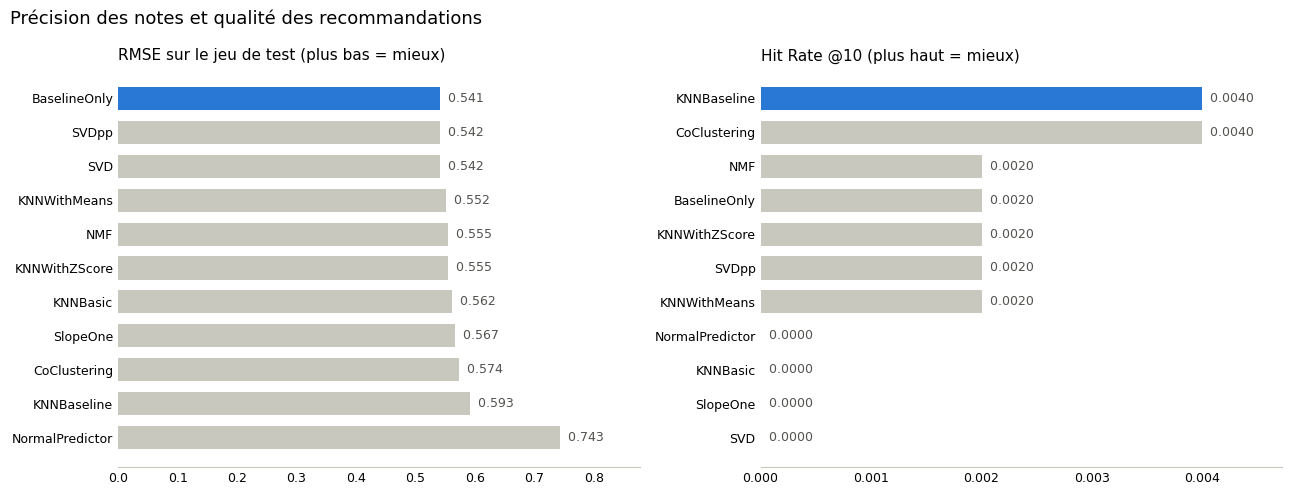

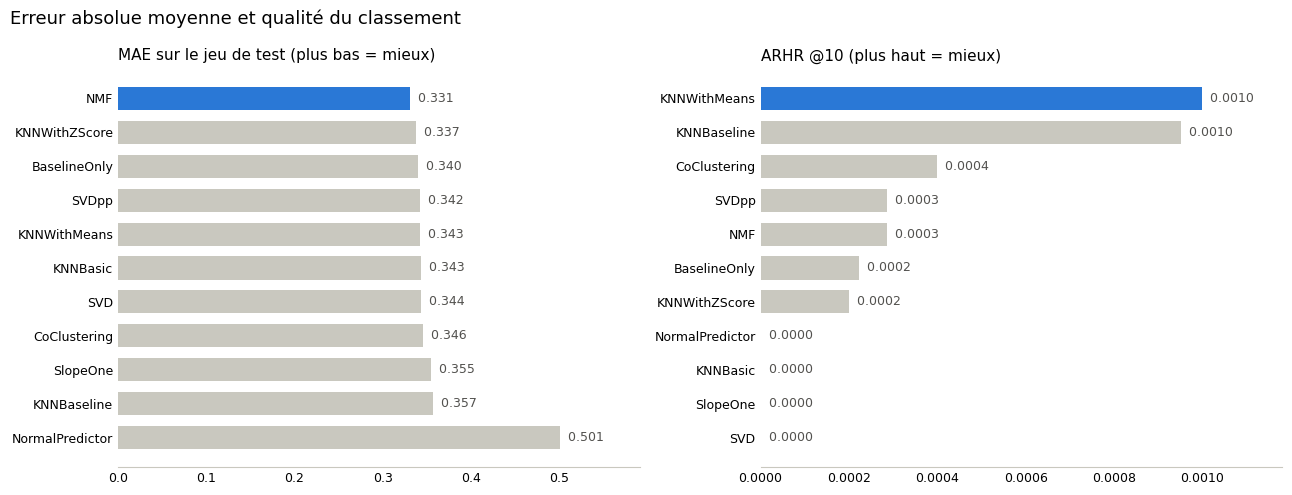

In [25]:
print("=" * 65)
print("COMPARAISON DES ALGORITHMES")
print("=" * 65)

colonnes = ["RMSE_test", "MAE_test", "HitRate", "cHR", "ARHR",
            "Couverture", "Diversite", "Nouveaute"]
comparaison = pd.DataFrame(resultats).T
tableau = comparaison[colonnes].sort_values("RMSE_test")
print(tableau.round(4))

BLEU, GRIS, ENCRE = "#2a78d6", "#c9c8bf", "#52514e"

def barres_comparatives(axe, serie, titre, meilleur="min", decimales=3):
    serie = serie.sort_values(ascending=(meilleur == "max"))
    cible = serie.index[-1]
    couleurs = [BLEU if nom == cible else GRIS for nom in serie.index]
    axe.barh(serie.index, serie.values, color=couleurs, height=0.68)
    for nom, valeur in serie.items():
        axe.text(valeur, nom, f"  {valeur:.{decimales}f}", va="center", ha="left",
                 fontsize=9, color=ENCRE)
    axe.set_title(titre, loc="left", fontsize=11)
    axe.set_xlim(0, serie.max() * 1.18)
    axe.tick_params(axis="both", length=0, labelsize=9)
    for cote in ("top", "right", "left"):
        axe.spines[cote].set_visible(False)
    axe.spines["bottom"].set_color(GRIS)
    axe.grid(False)

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
barres_comparatives(axes[0], tableau["RMSE_test"], "RMSE sur le jeu de test (plus bas = mieux)", "min", 3)
barres_comparatives(axes[1], tableau["HitRate"], "Hit Rate @10 (plus haut = mieux)", "max", 4)
figure.suptitle("Précision des notes et qualité des recommandations", x=0.01, ha="left", fontsize=13)
figure.tight_layout()
plt.show()

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
barres_comparatives(axes[0], tableau["MAE_test"], "MAE sur le jeu de test (plus bas = mieux)", "min", 3)
barres_comparatives(axes[1], tableau["ARHR"], "ARHR @10 (plus haut = mieux)", "max", 4)
figure.suptitle("Erreur absolue moyenne et qualité du classement", x=0.01, ha="left", fontsize=13)
figure.tight_layout()
plt.show()

On observe sur la précision des notes :
- BaselineOnly obtient la meilleure RMSE avec 0,5410
- SVDpp et SVD suivent avec 0,5417 et 0,5419
- dix algorithmes sur onze se tiennent entre 0,5410 et 0,5926
- le modèle le plus simple égale donc les modèles les plus complexes
- les biais d'utilisateur et de recette suffisent à expliquer l'essentiel des notes
- NormalPredictor reste seul en retrait avec 0,7432

On observe sur la qualité des listes :
- les Hit Rate vont de 0,000 à 0,004
- le meilleur résultat correspond à 2 recettes retrouvées sur 500
- une liste tirée au hasard obtiendrait 0,0018
- aucun algorithme ne fait donc vraiment mieux que le hasard
- le classement du Hit Rate ne ressemble pas à celui de la RMSE
- SVD obtient la troisième RMSE et un Hit Rate nul
- bien prédire une note ne suffit donc pas pour construire une bonne liste

Ces Hit Rate très faibles s'expliquent :
- les notes tournent autour de 4,74 et l'échelle s'arrête à 5
- les recettes du top 10 ne sont séparées que de 0,02 point, comme le montre la cellule suivante
- le classement devient alors presque arbitraire
- ce dataset se prête donc mal à l'évaluation par liste

On observe sur les trois dernières métriques :
- la couverture dépasse 99,8 % partout, car presque toutes les notes prédites dépassent 4
- la diversité reste comprise entre 0,996 et 1,000 pour tous les algorithmes
- les listes ne contiennent donc pas de recettes semblables entre elles
- la nouveauté varie beaucoup, de 1 989 pour BaselineOnly à 3 279 pour KNNBasic
- BaselineOnly propose les recettes les plus connues
- KNNBasic propose les recettes les plus rares

In [26]:
print("=" * 65)
print("RECOMMANDATION TOP-N POUR UN UTILISATEUR")
print("=" * 65)

MEILLEUR_ALGO = tableau["RMSE_test"].idxmin()
print("Algorithme retenu :", MEILLEUR_ALGO)
print("Hyperparamètres   :", meilleurs[MEILLEUR_ALGO])

classe_finale = grilles[MEILLEUR_ALGO][0]
modele_final = classe_finale(**meilleurs[MEILLEUR_ALGO])
modele_final.fit(trainset_complet)

catalogue = recipes.set_index("id")[["name", "note_moyenne", "nb_notes"]]

def recommander_topn(user_id, n=10):
    """Retourne les n recettes recommandées : recette, note moyenne, nombre de notes."""
    try:
        u_interne = trainset_complet.to_inner_uid(user_id)
    except ValueError:
        print(f"Utilisateur {user_id} inconnu du modèle -> recommandation par popularité.")
        populaires = (catalogue[catalogue["nb_notes"] >= 50]
                      .sort_values(["note_moyenne", "nb_notes"], ascending=False)
                      .head(n).reset_index(drop=True)
                      .rename(columns={"name": "recette", "nb_notes": "nombre_de_notes"}))
        populaires.index = range(1, len(populaires) + 1)
        return populaires[["recette", "note_moyenne", "nombre_de_notes"]].round(2)

    deja_vues = {j for j, _ in trainset_complet.ur[u_interne]}
    candidates = [trainset_complet.to_raw_iid(j)
                  for j in trainset_complet.all_items() if j not in deja_vues]
    estimations = [(iid, modele_final.predict(user_id, iid, verbose=False).est)
                   for iid in candidates]

    resultat = (pd.DataFrame(estimations, columns=["recipe_id", "note_predite"])
                .join(catalogue, on="recipe_id")
                .rename(columns={"name": "recette", "nb_notes": "nombre_de_notes"})
                .sort_values(["note_predite", "nombre_de_notes"], ascending=False)
                .head(n).reset_index(drop=True))
    resultat.index = range(1, len(resultat) + 1)
    return resultat[["recette", "note_moyenne", "nombre_de_notes", "note_predite"]].round(2)


utilisateur_exemple = cf["user_id"].value_counts().index[0]
profil = cf[cf["user_id"] == utilisateur_exemple]
print("-" * 65)
print("Utilisateur", utilisateur_exemple, ":", len(profil), "recettes notées,",
      "note moyenne", round(profil["rating"].mean(), 2))
print("-" * 65)
print(recommander_topn(utilisateur_exemple, 10))

print("=" * 65)
print("EXEMPLE SUR UN UTILISATEUR INCONNU (DÉMARRAGE À FROID)")
print("=" * 65)
print(recommander_topn(-1, 10))

RECOMMANDATION TOP-N POUR UN UTILISATEUR
Algorithme retenu : BaselineOnly
Hyperparamètres   : {'bsl_options': {'method': 'sgd', 'n_epochs': 20, 'reg_u': 12, 'reg_i': 5}, 'verbose': False}


-----------------------------------------------------------------
Utilisateur 140132 : 1443 recettes notées, note moyenne 4.73
-----------------------------------------------------------------
                                              recette  note_moyenne  nombre_de_notes  note_predite
1                        ww frozen peanut butter cups          4.90             50.0          5.00
2              grow your own magic doughnuts   donuts          5.00             30.0          5.00
3      how to bake a cake  with small children around          5.00             32.0          5.00
4                        my  famous  shredded chicken          5.00             38.0          5.00
5   caprese salad tomatoes  italian marinated toma...          5.00             52.0          4.99
6   red chili sauce   to be used with traditional ...          4.68             68.0          4.99
7           the original rice krispies treats squares          4.91            102.0          4.99
8              

On observe :
- l'algorithme retenu est BaselineOnly, qui obtient la plus faible RMSE de test
- l'utilisateur 140132 est le plus actif du noyau avec 1 443 recettes notées
- sa note moyenne vaut 4,73, très proche de la moyenne générale
- les notes prédites de son top 10 vont de 4,98 à 5,00
- ces valeurs sont très resserrées, le nombre de notes joue donc un rôle important dans le tri
- les recettes proposées ont toutes une note moyenne supérieure à 4,68
- elles ont toutes reçu au moins 21 notes, la recommandation s'appuie donc sur plusieurs avis
- l'utilisateur inconnu reçoit la liste des recettes les mieux notées, sans personnalisation